Gráfica generada en: /home/paco/Proyectos/WAID/plots/Graf_W.pdf


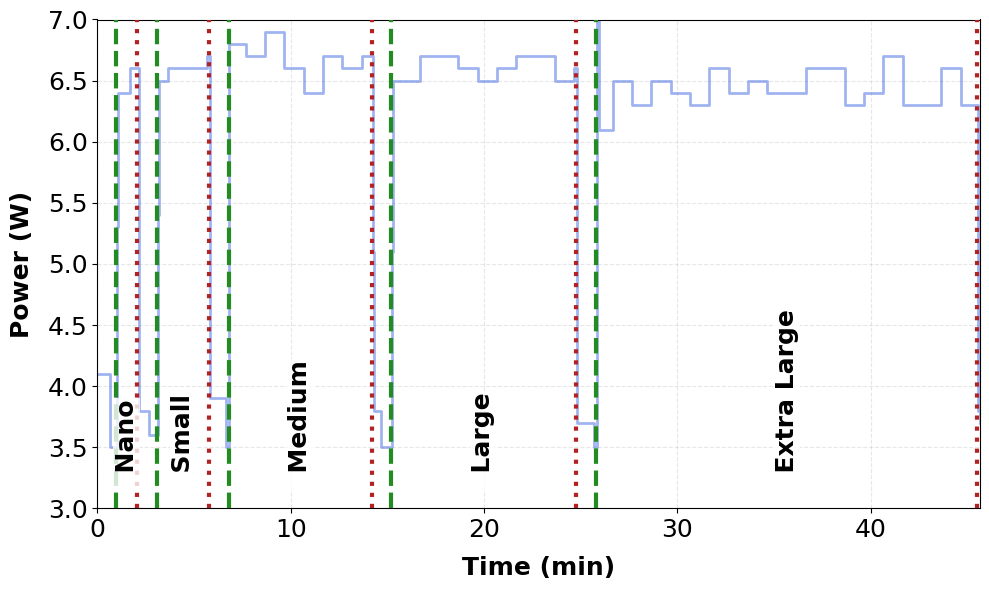


Modelo          | Media (W)  | STD      | Min      | Max     
----------------------------------------------------------------------
11n_1           | 6.456      | 0.232    | 6.3      | 6.8     
11s_1           | 6.684      | 0.139    | 6.5      | 7.0     
11m_1           | 6.482      | 0.105    | 6.3      | 6.6     
11l_1           | 6.58       | 0.206    | 5.0      | 6.9     
11x_1           | 6.37       | 0.177    | 6.0      | 7.0     
11n_2           | 6.487      | 0.145    | 6.3      | 6.6     
11s_2           | 6.47       | 0.166    | 6.0      | 6.6     
11m_2           | 6.496      | 0.127    | 6.3      | 6.7     
11l_2           | 6.519      | 0.188    | 5.6      | 6.7     
11x_2           | 6.417      | 0.125    | 6.3      | 6.7     
11n_3           | 6.547      | 0.088    | 6.4      | 6.6     
11s_3           | 6.57       | 0.362    | 4.7      | 6.8     
11m_3           | 6.594      | 0.124    | 6.4      | 6.8     
11l_3           | 6.64       | 0.127    | 6.3      | 6.8    

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


Device="Raspy8"

# --- Configuración de Rutas Relativas ---
try:
    # Si corre como script .py
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Si corre en Jupyter Notebook
    BASE_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, ".."))

LOG_DIR = os.path.join(PROJECT_ROOT, "logs", Device)
GRAPH_DIR = os.path.join(PROJECT_ROOT, "plots")

os.makedirs(GRAPH_DIR, exist_ok=True)

FILE_T = os.path.join(LOG_DIR, "Predic_t_resumen.csv")
FILE_W = os.path.join(LOG_DIR, "Predic_W.csv")

def obtener_intervalos_modelo(idx_pred):
    df_t = pd.read_csv(FILE_T)
    nombres_map = {'n': 'Nano', 's': 'Small', 'm': 'Medium', 'l': 'Large', 'x': 'Extra Large'}

    def parse_model(m):
        partes = m.split("_")
        nombre, idx = partes[0], int(partes[1])
        return nombres_map.get(nombre[-1], nombre[-1]), idx

    df_t[["nombre_full", "idx"]] = df_t["Modelo"].apply(lambda x: pd.Series(parse_model(x)))
    modelos_idx = df_t[df_t["idx"] == idx_pred].copy()
    
    for col in ["Inicio", "Fin"]:
        modelos_idx[col] = pd.to_datetime(modelos_idx[col])
        if modelos_idx[col].dt.tz is None:
            modelos_idx[col] = modelos_idx[col].dt.tz_localize("Europe/Madrid")
    return modelos_idx

def GrafPotencia_intervalo(idx_pred, margin_s=60):
    df_hitos = obtener_intervalos_modelo(idx_pred)
    if df_hitos.empty:
        return

    # Rango de tiempo con margen
    t_min_limit = df_hitos["Inicio"].min() - pd.Timedelta(seconds=margin_s)
    t_max_limit = df_hitos["Fin"].max() + pd.Timedelta(seconds=margin_s)

    # Carga de datos de potencia
    df_w = pd.read_csv(FILE_W)
    df_w["last_changed"] = pd.to_datetime(df_w["last_changed"], utc=True)
    df_w["last_changed_es"] = df_w["last_changed"].dt.tz_convert("Europe/Madrid")
    df_w["state"] = pd.to_numeric(df_w["state"], errors='coerce')
    df_w = df_w.dropna(subset=["state"])

    df_plot = df_w[(df_w["last_changed_es"] >= t_min_limit) &
                   (df_w["last_changed_es"] <= t_max_limit)].sort_values("last_changed_es")

    if df_plot.empty:
        return

    # --- Nuevo: tiempo relativo en minutos desde el inicio del intervalo ---
    t0 = df_plot["last_changed_es"].min()
    df_plot["t_rel_min"] = (df_plot["last_changed_es"] - t0).dt.total_seconds() / 60.0

    # Configuración de la figura
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    # Curva de potencia en función de minutos
    plt.step(df_plot["t_rel_min"], df_plot["state"], where="post",
             color="royalblue", alpha=0.5, linewidth=2, zorder=2)

    # Límites eje X: desde 0 hasta el máximo minuto
    x_max = df_plot["t_rel_min"].max()
    plt.xlim(0, x_max)
    plt.ylim(3, 7)

    # Ticks cada 10 minutos
    max_min = int(np.ceil(x_max))
    xticks = np.arange(0, max_min + 1, 10)
    ax.set_xticks(xticks)

    # Líneas verticales y etiquetas usando minutos relativos
    for _, fila in df_hitos.iterrows():
        x_inicio = (fila["Inicio"] - t0).total_seconds() / 60.0
        x_fin    = (fila["Fin"]    - t0).total_seconds() / 60.0
        plt.axvline(x_inicio, color="forestgreen", linestyle="--", linewidth=3, zorder=10)
        plt.axvline(x_fin,    color="firebrick",   linestyle=":",  linewidth=3, zorder=10)

        mid_time = (x_inicio + x_fin) / 2.0
        plt.text(mid_time, 3.15, f"  {fila['nombre_full']}",
                 rotation=90, verticalalignment='bottom', horizontalalignment='center',
                 fontweight='bold', fontsize=18, color='black',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1), zorder=11)

    # Etiquetas de ejes
    plt.xlabel("Time (min)", fontsize=18, labelpad=10, fontweight='bold')
    plt.ylabel("Power (W)", fontsize=18, labelpad=10, fontweight='bold')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, alpha=0.3, linestyle='--', zorder=1)
    plt.tight_layout()

    save_path = os.path.join(GRAPH_DIR, "Graf_W.pdf")
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    print(f"Gráfica generada en: {save_path}")
    plt.show()

def calcular_estadisticas_potencia():
    df_t = pd.read_csv(FILE_T)
    df_w = pd.read_csv(FILE_W)

    # Preparar tiempos y limpiar
    df_t["Inicio"] = pd.to_datetime(df_t["Inicio"]).dt.tz_localize("Europe/Madrid")
    df_t["Fin"] = pd.to_datetime(df_t["Fin"]).dt.tz_localize("Europe/Madrid")
    
    df_w["time_es"] = pd.to_datetime(df_w["last_changed"], utc=True).dt.tz_convert("Europe/Madrid")
    df_w["state"] = pd.to_numeric(df_w["state"], errors='coerce')
    df_w = df_w.dropna(subset=["state"]).sort_values("time_es")

    # Calcular delta_t (duración de cada muestra de potencia)
    df_w["delta_t"] = df_w["time_es"].diff().dt.total_seconds().shift(-1)
    df_w["delta_t"] = df_w["delta_t"].fillna(0)

    resultados = []
    muestras_globales = []
    deltas_globales = []

    for _, fila in df_t.iterrows():
        t_ini, t_fin = fila["Inicio"], fila["Fin"]
        mask = (df_w["time_es"] >= t_ini) & (df_w["time_es"] <= t_fin)
        df_m = df_w[mask].copy()

        if not df_m.empty:
            weights = df_m["delta_t"]
            vals = df_m["state"]
            
            # 1. Media Ponderada
            mean_w = np.average(vals, weights=weights)
            
            # 2. Desviación Típica Ponderada
            variance_w = np.average((vals - mean_w)**2, weights=weights)
            std_w = np.sqrt(variance_w)
            
            # 3. Max y Min
            max_w = vals.max()
            min_w = vals.min()

            resultados.append({
                "Modelo": fila["Modelo"],
                "Media_W": round(mean_w, 3),
                "STD_W": round(std_w, 3),
                "Min_W": round(min_w, 3),
                "Max_W": round(max_w, 3)
            })
            
            muestras_globales.extend(vals.tolist())
            deltas_globales.extend(weights.tolist())

    # --- Cálculos Globales ---
    df_resumen = pd.DataFrame(resultados)
    
    global_vals = np.array(muestras_globales)
    global_weights = np.array(deltas_globales)
    
    g_mean = np.average(global_vals, weights=global_weights)
    g_std = np.sqrt(np.average((global_vals - g_mean)**2, weights=global_weights))
    g_min = global_vals.min()
    g_max = global_vals.max()

    print("\n" + "="*70)
    print(f"{'Modelo':<15} | {'Media (W)':<10} | {'STD':<8} | {'Min':<8} | {'Max':<8}")
    print("-" * 70)
    for _, r in df_resumen.iterrows():
        print(f"{r['Modelo']:<15} | {r['Media_W']:<10} | {r['STD_W']:<8} | {r['Min_W']:<8} | {r['Max_W']:<8}")
    
    print("-" * 70)
    print(f"{'GLOBAL':<15} | {g_mean:<10.3f} | {g_std:<8.3f} | {g_min:<8.3f} | {g_max:<8.3f}")
    print("="*70)

    return df_resumen

if __name__ == "__main__":
    # Usamos el idx 4 como ejemplo
    GrafPotencia_intervalo(idx_pred=4, margin_s=60)
    calcular_estadisticas_potencia()